# Fase 1 — Extracción de Datos MT5

Extrae el historial completo de trades y los datos OHLC desde el bróker MEX Atlantic.
Todos los datos se guardan en `data/raw/` como Parquet.

In [1]:
import sys
import logging
import warnings
from pathlib import Path
from datetime import datetime, timezone

# ── project root on path ─────────────────────────────────────────────────────
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / "data" / "raw"
DATA_RAW.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.5f}".format)

print(f"Project root : {ROOT}")
print(f"Data raw dir : {DATA_RAW}")

Project root : C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering
Data raw dir : C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering\data\raw


## 1. Conexión MT5

In [2]:
from src.extraction.mt5_client import MT5Client

client = MT5Client(env_path=ROOT / ".env")
client.connect()

info = client.account_info()
print(f"Account  : {info.login}")
print(f"Name     : {info.name}")
print(f"Balance  : {info.balance:.2f} {info.currency}")
print(f"Server   : {info.server}")
print(f"Leverage : 1:{info.leverage}")
print(f"Trade mode: {'investor (read-only)' if info.trade_mode == 0 else info.trade_mode}")

INFO: Connected to MEXAtlantic-Real — account 921339, balance 2247.17 USD


Account  : 921339
Name     : SOLANGE DOS SANTOS DA SILVA
Balance  : 2247.17 USD
Server   : MEXAtlantic-Real
Leverage : 1:500
Trade mode: 2


## 2. Extracción del historial completo

In [3]:
from src.extraction.trade_history import get_full_history, save_trades

DATE_FROM = datetime(2026, 1, 1, tzinfo=timezone.utc)
DATE_TO   = datetime.now(timezone.utc)

print(f"Fetching history: {DATE_FROM.date()} → {DATE_TO.date()}")
df_all = get_full_history(DATE_FROM, DATE_TO, symbol_filter=None)

print(f"\nTotal trades extracted : {len(df_all)}")
print(f"Date range             : {df_all['open_time'].min().date()} → {df_all['open_time'].max().date()}")
print(f"\nSymbols found:")
print(df_all["symbol"].value_counts().to_string())

INFO: Raw deals fetched: 80


INFO: Reconstructed 35 trades (filter=None, window=2026-01-01 → 2026-05-04)


Fetching history: 2026-01-01 → 2026-05-04

Total trades extracted : 35
Date range             : 2026-03-19 → 2026-05-01

Symbols found:
symbol
XAUUSD..    35


## 3. Filtro XAUUSD — período objetivo

In [4]:
# All XAUUSD variants across the full window
df_xau = df_all[df_all["symbol"].str.startswith("XAUUSD")].copy().reset_index(drop=True)
print(f"XAUUSD trades (all dates): {len(df_xau)}")

# Target period: 2026-03-19 → 2026-04-27 (inclusive)
PERIOD_START = datetime(2026, 3, 19, tzinfo=timezone.utc)
PERIOD_END   = datetime(2026, 4, 28, tzinfo=timezone.utc)  # +1 day to capture late closes

mask = (
    (df_xau["open_time"] >= PERIOD_START) &
    (df_xau["open_time"] <  PERIOD_END)
)
df_target = df_xau[mask].copy().reset_index(drop=True)

print(f"\n=== TARGET PERIOD ({PERIOD_START.date()} → 2026-04-27) ===")
print(f"Trade count : {len(df_target)}  (ground truth: 30)")

if len(df_target) == 30:
    print("OK: Exactly 30 trades confirmed")
else:
    print(f"WARNING: Got {len(df_target)} trades — adjust PERIOD_END if needed")

print(f"\nActual symbol string used: {df_target['symbol'].unique()}")

XAUUSD trades (all dates): 35

=== TARGET PERIOD (2026-03-19 → 2026-04-27) ===
Trade count : 30  (ground truth: 30)
OK: Exactly 30 trades confirmed

Actual symbol string used: ['XAUUSD..']


In [5]:
# Display all 30 trades
cols_display = ["ticket", "side", "volume", "open_time", "open_price",
                "close_time", "close_price", "sl", "tp",
                "profit", "commission", "duration_min", "magic", "comment_open"]
df_target[cols_display].style.format({
    "open_price": "{:.2f}", "close_price": "{:.2f}",
    "sl": "{:.2f}", "tp": "{:.2f}",
    "profit": "{:+.2f}", "commission": "{:.2f}",
    "duration_min": "{:.0f}",
}).background_gradient(subset=["profit"], cmap="RdYlGn")

,ticket,side,volume,open_time,open_price,close_time,close_price,sl,tp,profit,commission,duration_min,magic,comment_open
0,413086299,buy,0.010000,2026-03-19 03:45:58.534000+00:00,4838.09,2026-03-19 04:37:28.946000+00:00,4857.95,0.00,0.00,+19.86,0.00,52,0,
1,413589012,sell,0.010000,2026-03-20 02:01:23.315000+00:00,4647.54,2026-03-20 04:06:15.425000+00:00,4673.35,0.00,0.00,-25.81,0.00,125,0,
2,414044287,sell,0.010000,2026-03-23 02:50:29.138000+00:00,4465.86,2026-03-23 03:15:30.897000+00:00,4413.71,0.00,0.00,+52.15,0.00,25,0,
3,414647846,buy,0.010000,2026-03-24 02:37:41.420000+00:00,4429.37,2026-03-24 03:28:19.814000+00:00,4375.18,0.00,0.00,-54.19,0.00,51,0,
4,414661794,sell,0.010000,2026-03-24 03:30:01.293000+00:00,4378.17,2026-03-24 05:12:18.015000+00:00,4307.99,0.00,0.00,+70.18,0.00,102,0,
5,415090558,buy,0.020000,2026-03-25 02:00:07.472000+00:00,4484.35,2026-03-25 02:25:15.666000+00:00,4502.02,0.00,0.00,+35.34,0.00,25,0,
6,415549986,buy,0.020000,2026-03-26 01:35:20.511000+00:00,4520.76,2026-03-26 01:44:18.299000+00:00,4533.48,0.00,0.00,+25.44,0.00,9,0,
7,416447591,sell,0.010000,2026-03-30 02:15:04.069000+00:00,4478.49,2026-03-30 02:35:36.147000+00:00,4452.42,0.00,0.00,+26.07,0.00,21,0,
8,416557098,buy,0.010000,2026-03-30 08:20:21.202000+00:00,4512.57,2026-03-30 08:58:22.632000+00:00,4525.31,0.00,0.00,+12.74,0.00,38,0,
9,416898251,buy,0.010000,2026-03-31 02:44:30.703000+00:00,4518.70,2026-03-31 03:20:17.044000+00:00,4484.11,0.00,0.00,-34.59,0.00,36,0,


## 4. Análisis exploratorio preliminar

In [6]:
print("=" * 55)
print("MAGIC NUMBER DISTRIBUTION")
print("0 = manual trading  |  non-zero = Expert Advisor")
print("=" * 55)
magic_vc = df_target["magic"].value_counts().reset_index()
magic_vc.columns = ["magic", "count"]
magic_vc["pct"] = (magic_vc["count"] / len(df_target) * 100).round(1)
print(magic_vc.to_string(index=False))

MAGIC NUMBER DISTRIBUTION
0 = manual trading  |  non-zero = Expert Advisor


 magic  count       pct
     0     30 100.00000


In [7]:
print("=" * 55)
print("COMMENT ANALYSIS  ← CRITICAL for strategy type")
print("=" * 55)

print("\n--- comment_open (entry comments) ---")
print(df_target["comment_open"].value_counts().to_string())

print("\n--- comment_close (exit comments) ---")
print(df_target["comment_close"].value_counts().to_string())

print("\n--- SL/TP presence ---")
has_sl = (df_target["sl"] > 0).sum()
has_tp = (df_target["tp"] > 0).sum()
print(f"Trades with SL set : {has_sl}/{len(df_target)}")
print(f"Trades with TP set : {has_tp}/{len(df_target)}")

if has_sl > 0:
    sl_pips = ((df_target["open_price"] - df_target["sl"]).abs() * 10).where(
        df_target["sl"] > 0
    ).dropna()
    tp_pips = ((df_target["tp"] - df_target["open_price"]).abs() * 10).where(
        df_target["tp"] > 0
    ).dropna()
    print(f"\nSL distance (pips): mean={sl_pips.mean():.1f}  min={sl_pips.min():.1f}  max={sl_pips.max():.1f}")
    if len(tp_pips) > 0:
        print(f"TP distance (pips): mean={tp_pips.mean():.1f}  min={tp_pips.min():.1f}  max={tp_pips.max():.1f}")
        rr = tp_pips / sl_pips
        print(f"Risk:Reward ratio : mean={rr.mean():.2f}")

COMMENT ANALYSIS  ← CRITICAL for strategy type

--- comment_open (entry comments) ---
comment_open
    30

--- comment_close (exit comments) ---
comment_close
                17
[sl 4672.74]     1
[tp 4413.73]     1
[sl 4376.64]     1
[tp 4308.07]     1
[sl 4492.32]     1
[sl 4663.71]     1
[sl 4651.94]     1
[tp 4759.04]     1
[tp 4826.44]     1
[sl 4791.18]     1
[tp 4789.58]     1
[sl 4684.96]     1
[tp 4727.34]     1

--- SL/TP presence ---
Trades with SL set : 0/30
Trades with TP set : 0/30


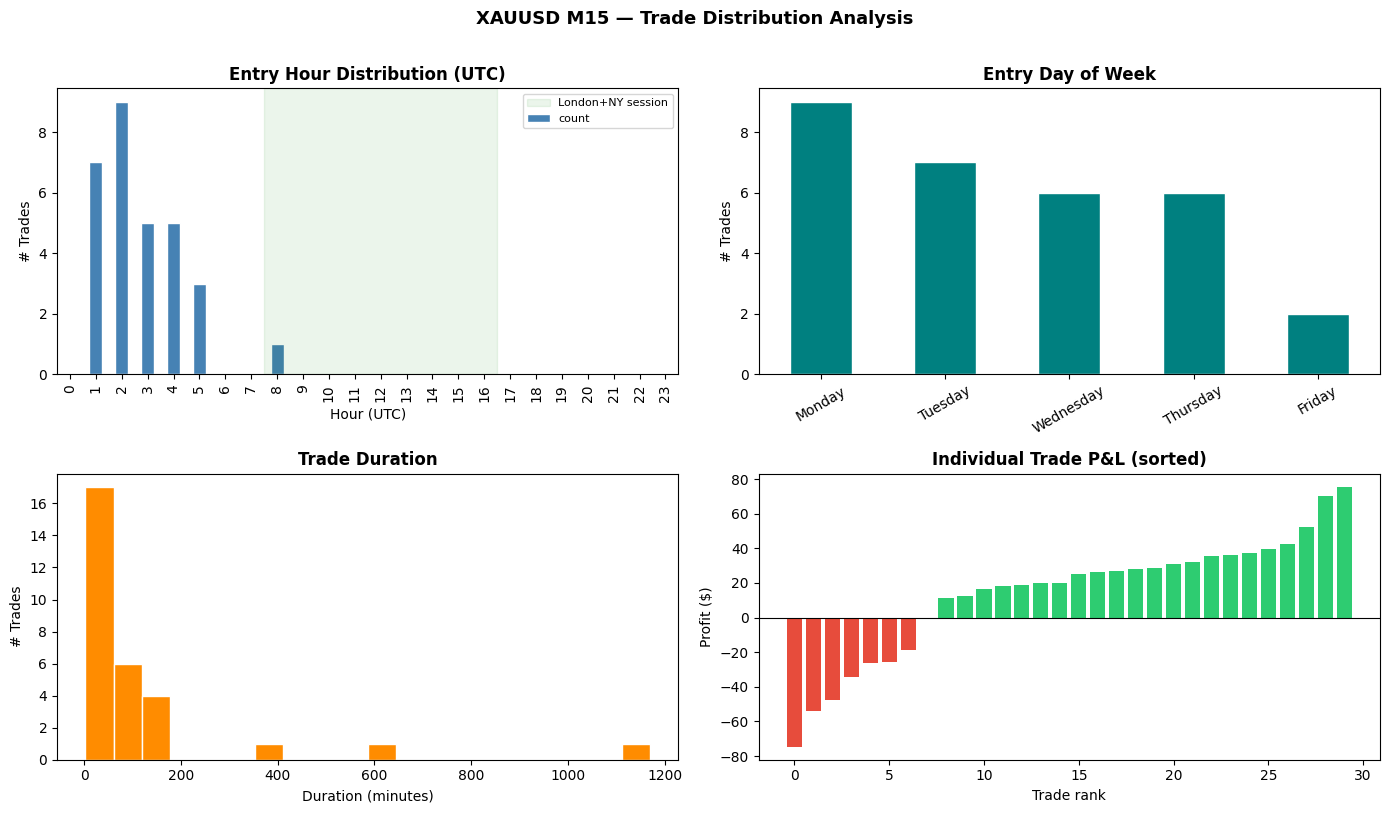

In [8]:
df_target["hour_utc"]  = df_target["open_time"].dt.hour
df_target["dayofweek"] = df_target["open_time"].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Hour distribution
hour_counts = df_target["hour_utc"].value_counts().sort_index().reindex(range(24), fill_value=0)
hour_counts.plot.bar(ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Entry Hour Distribution (UTC)", fontweight="bold")
axes[0, 0].set_xlabel("Hour (UTC)")
axes[0, 0].set_ylabel("# Trades")
axes[0, 0].axvspan(7.5, 16.5, alpha=0.08, color="green", label="London+NY session")
axes[0, 0].legend(fontsize=8)

# Day of week
dow_order  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
dow_counts = df_target["dayofweek"].value_counts().reindex(dow_order, fill_value=0)
dow_counts.plot.bar(ax=axes[0, 1], color="teal", edgecolor="white")
axes[0, 1].set_title("Entry Day of Week", fontweight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("# Trades")
axes[0, 1].tick_params(axis="x", rotation=30)

# Duration
df_target["duration_min"].plot.hist(ax=axes[1, 0], bins=20, color="darkorange", edgecolor="white")
axes[1, 0].set_title("Trade Duration", fontweight="bold")
axes[1, 0].set_xlabel("Duration (minutes)")
axes[1, 0].set_ylabel("# Trades")

# Profit distribution — colors must match sorted order
sorted_profits = df_target["profit"].sort_values().values
bar_colors     = ["#2ecc71" if p > 0 else "#e74c3c" for p in sorted_profits]
axes[1, 1].bar(range(len(df_target)), sorted_profits, color=bar_colors)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Individual Trade P&L (sorted)", fontweight="bold")
axes[1, 1].set_xlabel("Trade rank")
axes[1, 1].set_ylabel("Profit ($)")

plt.suptitle("XAUUSD M15 — Trade Distribution Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

P&L SUMMARY
Total trades    : 30
Wins            : 22  (73.3%)  ← ground truth: 73%
Losses          : 8  (26.7%)
Avg win         : $32.00
Avg loss        : $-35.33
Profit factor   : 2.49
---
Gross profit    : $421.40
Commission      : $0.00
Swap            : $-1.33
Net P&L         : $420.07  ← ground truth: +$421.40
---
Avg duration    : 124 min
Volume mode     : 0.01 lots


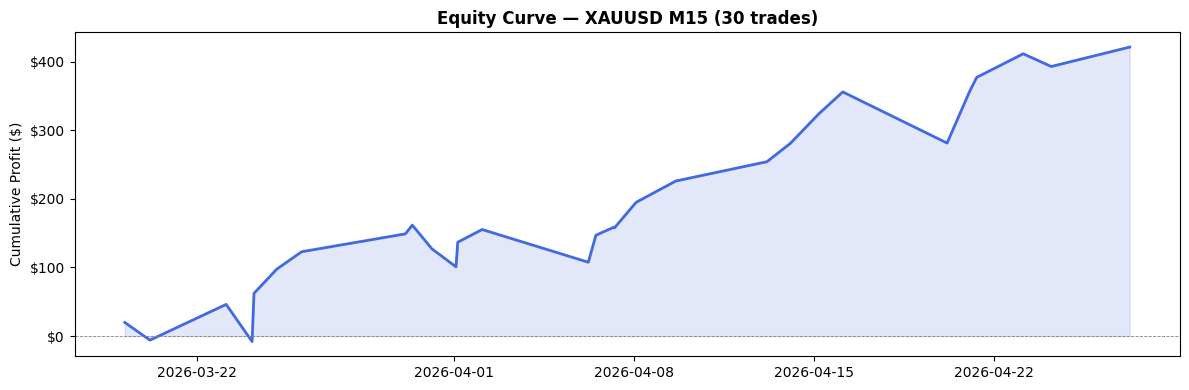

In [9]:
wins   = (df_target["profit"] > 0)
losses = (df_target["profit"] <= 0)

gross  = df_target["profit"].sum()
comm   = df_target["commission"].sum()
swap   = df_target["swap"].sum()
net    = gross + comm + swap

avg_win  = df_target.loc[wins,  "profit"].mean()
avg_loss = df_target.loc[losses, "profit"].mean()
pf       = df_target.loc[wins, "profit"].sum() / df_target.loc[losses, "profit"].abs().sum()

print("=" * 45)
print("P&L SUMMARY")
print("=" * 45)
print(f"Total trades    : {len(df_target)}")
print(f"Wins            : {wins.sum()}  ({100*wins.mean():.1f}%)  ← ground truth: 73%")
print(f"Losses          : {losses.sum()}  ({100*losses.mean():.1f}%)")
print(f"Avg win         : ${avg_win:.2f}")
print(f"Avg loss        : ${avg_loss:.2f}")
print(f"Profit factor   : {pf:.2f}")
print(f"---")
print(f"Gross profit    : ${gross:.2f}")
print(f"Commission      : ${comm:.2f}")
print(f"Swap            : ${swap:.2f}")
print(f"Net P&L         : ${net:.2f}  ← ground truth: +$421.40")
print(f"---")
print(f"Avg duration    : {df_target['duration_min'].mean():.0f} min")
print(f"Volume mode     : {df_target['volume'].mode().iloc[0]} lots")

# Equity curve
fig, ax = plt.subplots(figsize=(12, 4))
equity = df_target["profit"].cumsum()
ax.plot(df_target["close_time"], equity, color="royalblue", linewidth=2)
ax.fill_between(df_target["close_time"], equity, alpha=0.15, color="royalblue")
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_title("Equity Curve — XAUUSD M15 (30 trades)", fontweight="bold")
ax.set_ylabel("Cumulative Profit ($)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("$%.0f"))
plt.tight_layout()
plt.show()

In [10]:
print("=" * 45)
print("DIRECTION ANALYSIS")
print("=" * 45)
side_vc = df_target["side"].value_counts()
print(side_vc.to_string())

# Win rate per direction
for side, grp in df_target.groupby("side"):
    wr = (grp["profit"] > 0).mean()
    print(f"\n  {side.upper()} — {len(grp)} trades, win rate {100*wr:.1f}%, total P&L ${grp['profit'].sum():.2f}")

DIRECTION ANALYSIS
side
buy     20
sell    10

  BUY — 20 trades, win rate 80.0%, total P&L $372.19

  SELL — 10 trades, win rate 60.0%, total P&L $49.21


## 5. Descarga de datos OHLC

In [11]:
from src.extraction.market_data import download_all_timeframes, TIMEFRAME_MAP

# Use the actual symbol string from the real trades
SYMBOL     = str(df_target["symbol"].iloc[0])
OHLC_START = datetime(2026, 2, 1, tzinfo=timezone.utc)
OHLC_END   = datetime(2026, 5, 1, tzinfo=timezone.utc)

print(f"Symbol    : {SYMBOL}")
print(f"Period    : {OHLC_START.date()} → {OHLC_END.date()}")
print(f"Output    : {DATA_RAW}")
print()

saved = download_all_timeframes(SYMBOL, OHLC_START, OHLC_END, DATA_RAW)

print()
print(f"{'TF':<6} {'Bars':>8} {'Size KB':>9}  File")
print("-" * 50)
for tf, path in sorted(saved.items(), key=lambda x: list(TIMEFRAME_MAP).index(x[0])):
    df_tmp  = pd.read_parquet(path)
    size_kb = path.stat().st_size / 1024
    print(f"{tf:<6} {len(df_tmp):>8,} {size_kb:>9.1f}  {path.name}")

Window: 2026-02-01 00:00:00+00:00 → 2026-05-01 00:00:00+00:00


INFO: XAUUSD.. M5: 17347 bars  [2026-02-02 → 2026-04-30]


Symbol    : XAUUSD..
Period    : 2026-02-01 → 2026-05-01
Output    : C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering\data\raw



INFO: XAUUSD.. M15: 5786 bars  [2026-02-02 → 2026-04-30]


INFO: XAUUSD.. M30: 2893 bars  [2026-02-02 → 2026-04-30]


INFO: XAUUSD.. H1: 1447 bars  [2026-02-02 → 2026-04-30]


INFO: XAUUSD.. H4: 379 bars  [2026-02-02 → 2026-05-01]


INFO: XAUUSD.. D1: 64 bars  [2026-02-02 → 2026-05-01]



TF         Bars   Size KB  File
--------------------------------------------------


M5       17,347     590.8  bars_XAUUSD.._M5.parquet
M15       5,786     219.2  bars_XAUUSD.._M15.parquet
M30       2,893     115.3  bars_XAUUSD.._M30.parquet
H1        1,447      61.4  bars_XAUUSD.._H1.parquet
H4          379      20.2  bars_XAUUSD.._H4.parquet
D1           64       7.9  bars_XAUUSD.._D1.parquet


In [12]:
# Verify M15 data integrity — check for unexpected gaps
m15_path = DATA_RAW / f"bars_{SYMBOL}_M15.parquet"
df_m15   = pd.read_parquet(m15_path)
df_m15.index = pd.to_datetime(df_m15.index)

# On weekdays only (weekend gaps are expected)
df_weekday = df_m15[df_m15.index.dayofweek < 5]
diffs      = df_weekday.index.to_series().diff().dropna()
gaps       = diffs[diffs > pd.Timedelta("30min")]  # > 2 consecutive M15 bars missing

print(f"M15 total bars       : {len(df_m15):,}")
print(f"Weekday bars         : {len(df_weekday):,}")
print(f"Unexpected gaps >30m : {len(gaps)}")

if len(gaps) > 0:
    print("\nGap locations:")
    for ts, gap in gaps.items():
        print(f"  {ts}  (gap: {gap})")
else:
    print("OK: No significant gaps in M15 data")

print(f"\nM15 sample (last 3 bars):")
print(df_m15.tail(3))

M15 total bars       : 5,786
Weekday bars         : 5,786
Unexpected gaps >30m : 62

Gap locations:
  2026-02-03 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-04 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-05 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-06 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-09 01:00:00+00:00  (gap: 2 days 01:15:00)
  2026-02-10 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-11 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-12 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-13 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-16 01:00:00+00:00  (gap: 2 days 01:15:00)
  2026-02-17 01:00:00+00:00  (gap: 0 days 03:45:00)
  2026-02-18 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-19 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-20 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-23 01:00:00+00:00  (gap: 2 days 01:15:00)
  2026-02-24 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-25 01:00:00+00:00  (gap: 0 days 01:15:00)
  2026-02-26 01:

## 6. Guardar trades en Parquet

In [13]:
from src.extraction.trade_history import save_trades

files_saved = {}

p1 = DATA_RAW / "trades_all_symbols.parquet"
save_trades(df_all, p1)
files_saved["all symbols"] = p1

p2 = DATA_RAW / "trades_XAUUSD_full.parquet"
save_trades(df_xau, p2)
files_saved["XAUUSD all dates"] = p2

p3 = DATA_RAW / "trades_XAUUSD_target.parquet"
save_trades(df_target, p3)
files_saved["XAUUSD target"] = p3

print("Trade files saved:")
for label, path in files_saved.items():
    size_kb = path.stat().st_size / 1024
    rows = pd.read_parquet(path).shape[0]
    print(f"  [{label}]  {path.name}  ({rows} rows, {size_kb:.1f} KB)")

INFO: Trades saved → trades_all_symbols.parquet  (35 rows, 12.1 KB)


INFO: Trades saved → trades_XAUUSD_full.parquet  (35 rows, 12.1 KB)


INFO: Trades saved → trades_XAUUSD_target.parquet  (30 rows, 12.9 KB)


Trade files saved:
  [all symbols]  trades_all_symbols.parquet  (35 rows, 12.1 KB)
  [XAUUSD all dates]  trades_XAUUSD_full.parquet  (35 rows, 12.1 KB)
  [XAUUSD target]  trades_XAUUSD_target.parquet  (30 rows, 12.9 KB)


## 7. Resumen final

In [14]:
print("=" * 60)
print("FASE 1 COMPLETA — ARCHIVOS GENERADOS")
print("=" * 60)

all_parquet = sorted(DATA_RAW.glob("*.parquet"))
total_kb = 0.0
for f in all_parquet:
    size_kb  = f.stat().st_size / 1024
    total_kb += size_kb
    rows     = pd.read_parquet(f).shape[0]
    print(f"  {f.name:<45} {rows:>7,} rows  {size_kb:>8.1f} KB")

print(f"{'─'*60}")
print(f"  {'TOTAL':45} {total_kb/1024:>7.2f} MB")
print()
print("Next step → notebooks/02_eda.ipynb")

client.disconnect()
print("\nMT5 connection closed.")

INFO: MT5 connection closed.


FASE 1 COMPLETA — ARCHIVOS GENERADOS
  bars_XAUUSD.._D1.parquet                           64 rows       7.9 KB
  bars_XAUUSD.._H1.parquet                        1,447 rows      61.4 KB
  bars_XAUUSD.._H4.parquet                          379 rows      20.2 KB
  bars_XAUUSD.._M15.parquet                       5,786 rows     219.2 KB
  bars_XAUUSD.._M30.parquet                       2,893 rows     115.3 KB
  bars_XAUUSD.._M5.parquet                       17,347 rows     590.8 KB
  trades_all_symbols.parquet                         35 rows      12.1 KB
  trades_XAUUSD_full.parquet                         35 rows      12.1 KB
  trades_XAUUSD_target.parquet                       30 rows      12.9 KB
────────────────────────────────────────────────────────────
  TOTAL                                            1.03 MB

Next step → notebooks/02_eda.ipynb

MT5 connection closed.
